# Notebook 1: Data Preprocessing

This is the first notebook in the series of three/four notebooks in this subdirectory. It serves as a preliminary and data preprocessing for the other notebook, starting from the given Excel sheet.

## 0. Environment Setup

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

import warnings
warnings.filterwarnings('ignore')

In [35]:
# Path declarations
WORKBOOK_NAME = "GPS Races for LRL Practice Round.xlsx"

candidate_paths = [
    Path(WORKBOOK_NAME),
    Path("../data/raw") / WORKBOOK_NAME
]

RAW_XLSX_PATH = None
for path in candidate_paths:
    if path.exists():
        RAW_XLSX_PATH = path
        break

if RAW_XLSX_PATH is None:
    raise FileNotFoundError(
        f"Could not find {WORKBOOK_NAME}. Double check the raw path."
    )

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw notebook path: {RAW_XLSX_PATH}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Raw notebook path: ../data/raw/GPS Races for LRL Practice Round.xlsx
Output directory: /Users/amourtu1934/Documents/4. Personal Projects/horse-racing-prediction/data/processed


## 1. Data Loading

In [36]:
# Gather basic information about the given Excel sheet
workbook = pd.ExcelFile(RAW_XLSX_PATH)

sheet_inventory = pd.DataFrame({
    "sheet_name": workbook.sheet_names
})

sheet_inventory["n_rows"] = [
    workbook.parse(name).shape[0] for name in workbook.sheet_names
]

sheet_inventory["n_cols"] = [
    workbook.parse(name).shape[1] for name in workbook.sheet_names
]

display(sheet_inventory)

,sheet_name,n_rows,n_cols
0,Laurel Park GPS races (past 60d,14642,25
1,Starters pps (relating to Laure,2897,36
2,GPS PPS,31174,26
3,notes,1,1


In [37]:
# Read the three main tabs
laurel_raw = workbook.parse("Laurel Park GPS races (past 60d")
pps_raw    = workbook.parse("Starters pps (relating to Laure")
gps_pp_raw = workbook.parse("GPS PPS")

print("Laurel raw shape:", laurel_raw.shape)
print("Traditional PP raw shape:", pps_raw.shape)
print("GPS PP raw shape:", gps_pp_raw.shape)

Laurel raw shape: (14642, 25)
Traditional PP raw shape: (2897, 36)
GPS PP raw shape: (31174, 26)


Note that, all three current tabs (Laurel, Starter past-performance, and Starter GPS PPS) are all at gate leve.

In [38]:
# Helper function
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Lowercase column names and replace punctuation/space with underscores
    """
    out = df.copy()
    out.columns = (
        pd.Index(out.columns)
        .str.strip()
        .str.lower()
        .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
        .str.strip("_")
    )
    return out

## 2. Preliminary Data Exploration

We now look at the three dataframes and figure out what the problems in each, and fix them as we go.

### i. Laurel Park GPS Race DataFrame

In [39]:
# View of first 10 rows
laurel_raw.head(10)

,track_id,race_date,race_number,distance_id,distance_unit,about_distance_indicator,Distance,surface,race_type,grade,Purse,registration_number,horse_name,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides
0,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,0.0,7,7,7.45,90.517,2.057,27.5,100.6,1417.6,16.6,216.0
1,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,0.5,7,7,7.13,83.068,1.424,20.2,100.6,1317.0,16.4,199.4
2,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,1.0,7,7,7.06,75.939,1.269,18.2,100.6,1216.4,16.4,183.0
3,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,1.5,6,7,7.32,68.874,1.250,18.3,103.8,1115.8,16.8,166.6
4,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,2.0,5,7,6.98,61.555,1.098,16.3,104.6,1012.0,16.4,149.8
5,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,2.5,5,7,6.61,54.572,0.970,14.7,102.5,907.4,16.0,133.4
6,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,3.0,7,7,6.21,47.956,0.926,14.4,100.7,804.9,15.0,117.4
7,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,3.5,6,7,5.95,41.749,0.819,13.3,100.6,704.2,14.4,102.4
8,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,4.0,6,7,5.90,35.806,0.671,11.2,100.6,603.6,14.2,88.0
9,LRL,2025-12-12,1,7.0,F,,7F,D,SOC,,27900,19002714,Mischief Motion,4,4.5,6,7,5.73,29.910,0.622,10.7,100.6,503.0,13.9,73.8


In [40]:
# Normalize column names and check data types
laurel_raw = standardize_columns(laurel_raw)
laurel_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14642 entries, 0 to 14641
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   track_id                  14642 non-null  object        
 1   race_date                 14642 non-null  datetime64[ns]
 2   race_number               14642 non-null  int64         
 3   distance_id               14642 non-null  float64       
 4   distance_unit             14642 non-null  object        
 5   about_distance_indicator  14642 non-null  object        
 6   distance                  14642 non-null  object        
 7   surface                   14642 non-null  object        
 8   race_type                 14642 non-null  object        
 9   grade                     14642 non-null  object        
 10  purse                     14642 non-null  int64         
 11  registration_number       14642 non-null  object        
 12  horse_name        

By our visual inspection, we expect that there should be quite a lot of missing data in at least the `about_distance_indicator`

In [41]:
# Count the number of unique count in each column
laurel_raw_unique_counts = (
    laurel_raw.nunique(dropna=False)
    .reset_index()
)
laurel_raw_unique_counts.columns = ["column", "num_unique_values"]
display(laurel_raw_unique_counts)

,column,num_unique_values
0,track_id,1
1,race_date,17
2,race_number,10
3,distance_id,7
4,distance_unit,1
5,about_distance_indicator,1
6,distance,7
7,surface,1
8,race_type,8
9,grade,1


There are a couple of columns that have a single value, like `track_id` ("LRL"), `distance_unit` ("F"), `about_distance_indicator` (" "), `surface` ("D"), and `grade` (" "). We will keep `track_id` so that we can create stable IDs later. There might be adding values in `distance unit` and `surface`. Thus, we will keep those two columns while dropping the other two.

In [42]:
# Drop about_distance_indicator and grade
laurel_raw.drop(
    columns=["about_distance_indicator", "grade"],
    inplace=True,
    errors="ignore"
)

laurel_raw.head(10)

,track_id,race_date,race_number,distance_id,distance_unit,distance,surface,race_type,purse,registration_number,horse_name,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides
0,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,0.0,7,7,7.45,90.517,2.057,27.5,100.6,1417.6,16.6,216.0
1,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,0.5,7,7,7.13,83.068,1.424,20.2,100.6,1317.0,16.4,199.4
2,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,1.0,7,7,7.06,75.939,1.269,18.2,100.6,1216.4,16.4,183.0
3,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,1.5,6,7,7.32,68.874,1.250,18.3,103.8,1115.8,16.8,166.6
4,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,2.0,5,7,6.98,61.555,1.098,16.3,104.6,1012.0,16.4,149.8
5,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,2.5,5,7,6.61,54.572,0.970,14.7,102.5,907.4,16.0,133.4
6,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,3.0,7,7,6.21,47.956,0.926,14.4,100.7,804.9,15.0,117.4
7,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,3.5,6,7,5.95,41.749,0.819,13.3,100.6,704.2,14.4,102.4
8,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,4.0,6,7,5.90,35.806,0.671,11.2,100.6,603.6,14.2,88.0
9,LRL,2025-12-12,1,7.0,F,7F,D,SOC,27900,19002714,Mischief Motion,4,4.5,6,7,5.73,29.910,0.622,10.7,100.6,503.0,13.9,73.8


In [43]:
# Check for duplicated values in the dataframe
duplicated = laurel_raw.duplicated().sum()
print(f"Number of duplicated observations: {duplicated}")

Number of duplicated observations: 0


Good news is that there is no duplicated values in this dataframe. Yay!

### ii. PPS Raw DataFrame

In [44]:
# First 10 rows of pps_raw
pps_raw.head(10)

,gps_date?,registration_number,horse_name,pp_track,pp_race_date,pp_race_number,pp_country,race_type,grade,distance_id,distance_unit,about_distance_indicator,Distance,surface,post_position,position_at_point_of_call_1,position_at_point_of_call_2,position_at_point_of_call_3,position_at_point_of_call_4,position_at_point_of_call_5,official_position,length_behind_at_poc_1,length_behind_at_poc_2,length_behind_at_poc_3,length_behind_at_poc_4,length_behind_at_poc_5,length_behind_at_finish,length_ahead_at_poc_1,length_ahead_at_poc_2,length_ahead_at_poc_3,length_ahead_at_poc_4,length_ahead_at_poc_5,length_ahead_at_finish,post_time_odds,field_size,Purse
0,,22017307,A Cozy Thing,MED,2025-10-10,4,USA,AOC,,5.0,F,,5F,T,11,9,9,0,0,5,3,810,780,0,0,750,325,100,200,0,0,10,100,144,11,53550
1,,22017307,A Cozy Thing,CT,2025-10-30,1,USA,CLM,,6.5,F,,6 1/2F,D,4,6,5,0,0,4,3,770,700,0,0,650,460,300,200,0,0,300,50,27,7,21500
2,X,22017307,A Cozy Thing,LRL,2025-11-28,2,USA,SOC,,8.0,F,,1M,D,4,5,7,6,0,5,4,170,420,570,0,810,575,100,200,150,0,400,500,208,8,25740
3,X,21003092,A P M Notion,LRL,2025-10-25,7,USA,CLM,,6.0,F,,6F,D,6,6,4,0,0,4,4,520,410,0,0,550,975,150,100,0,0,250,50,84,8,25700
4,X,21003092,A P M Notion,LRL,2025-11-15,10,USA,CLM,,5.5,F,,5 1/2F,D,4,6,6,0,0,7,6,560,800,0,0,1100,1525,250,150,0,0,0,50,181,7,23220
5,X,21003092,A P M Notion,LRL,2025-12-07,1,USA,CLM,,6.0,F,,6F,D,8,6,6,0,0,5,4,460,1160,0,0,850,625,10,50,0,0,200,100,830,8,23390
6,X,21003092,A P M Notion,LRL,2025-11-15,10,USA,CLM,,5.5,F,,5 1/2F,D,4,6,6,0,0,7,6,560,800,0,0,1100,1525,250,150,0,0,0,50,181,7,23220
7,X,21003092,A P M Notion,LRL,2025-12-07,1,USA,CLM,,6.0,F,,6F,D,8,6,6,0,0,5,4,460,1160,0,0,850,625,10,50,0,0,200,100,830,8,23390
8,X,21003092,A P M Notion,LRL,2025-12-28,6,USA,CLM,,7.0,F,,7F,D,5,3,2,0,0,4,8,300,100,0,0,550,2225,10,100,0,0,150,275,606,9,24550
9,X,21003092,A P M Notion,LRL,2025-12-07,1,USA,CLM,,6.0,F,,6F,D,8,6,6,0,0,5,4,460,1160,0,0,850,625,10,50,0,0,200,100,830,8,23390


In [45]:
# Standardize column names and rename gps_date? to has_gps_data
pps_raw = standardize_columns(pps_raw)
pps_raw = pps_raw.rename(columns={"gps_date": "has_gps_data"})

In [46]:
# List out the columns and their data types
pps_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2897 entries, 0 to 2896
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   has_gps_data                 2897 non-null   object        
 1   registration_number          2897 non-null   object        
 2   horse_name                   2897 non-null   object        
 3   pp_track                     2897 non-null   object        
 4   pp_race_date                 2897 non-null   datetime64[ns]
 5   pp_race_number               2897 non-null   int64         
 6   pp_country                   2897 non-null   object        
 7   race_type                    2897 non-null   object        
 8   grade                        2897 non-null   object        
 9   distance_id                  2897 non-null   float64       
 10  distance_unit                2897 non-null   object        
 11  about_distance_indicator     2897 non-null 

In [47]:
# Numeric data summary
pps_raw.describe()

,pp_race_date,pp_race_number,distance_id,post_position,position_at_point_of_call_1,position_at_point_of_call_2,position_at_point_of_call_3,position_at_point_of_call_4,position_at_point_of_call_5,official_position,length_behind_at_poc_1,length_behind_at_poc_2,length_behind_at_poc_3,length_behind_at_poc_4,length_behind_at_poc_5,length_behind_at_finish,length_ahead_at_poc_1,length_ahead_at_poc_2,length_ahead_at_poc_3,length_ahead_at_poc_4,length_ahead_at_poc_5,length_ahead_at_finish,post_time_odds,field_size,purse
count,2897,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2897.000000,2.897000e+03
mean,2025-10-21 09:54:59.275112192,5.265102,6.866130,4.454953,4.417673,4.261995,1.478771,0.009320,4.177425,4.106662,417.623749,446.653780,156.395582,4.321367,551.664826,753.806006,139.180532,144.292717,65.152917,3.486020,214.602347,308.291681,139.876769,7.847428,4.515887e+04
min,2024-06-01 00:00:00,1.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,7.900000e+03
25%,2025-10-09 00:00:00,3.000000,6.000000,2.000000,2.000000,2.000000,0.000000,0.000000,2.000000,2.000000,100.000000,100.000000,0.000000,0.000000,150.000000,175.000000,10.000000,10.000000,0.000000,0.000000,10.000000,50.000000,30.000000,7.000000,2.552000e+04
50%,2025-11-08 00:00:00,5.000000,6.500000,4.000000,4.000000,4.000000,0.000000,0.000000,4.000000,4.000000,310.000000,340.000000,0.000000,0.000000,450.000000,550.000000,100.000000,100.000000,0.000000,0.000000,150.000000,150.000000,65.000000,8.000000,3.200000e+04
75%,2025-11-29 00:00:00,7.000000,8.000000,6.000000,6.000000,6.000000,2.000000,0.000000,6.000000,6.000000,610.000000,660.000000,150.000000,0.000000,810.000000,1050.000000,200.000000,200.000000,50.000000,0.000000,250.000000,375.000000,159.000000,9.000000,5.000000e+04
max,2026-01-23 00:00:00,15.000000,20.000000,13.000000,13.000000,12.000000,12.000000,9.000000,12.000000,12.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,10450.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,1613.000000,14.000000,2.000000e+06
std,NaN,2.763615,1.211301,2.504855,2.490355,2.475023,2.438678,0.256644,2.425464,2.410128,521.781838,546.289172,405.185060,188.753272,672.570361,923.407127,397.237821,399.100136,304.247679,185.781532,540.965535,667.528939,193.148805,1.805700,6.883020e+04


In [48]:
# Count the number of unique count in each column
pps_raw_unique_counts = (
    pps_raw.nunique(dropna=False)
    .reset_index()
)

pps_raw_unique_counts.columns = ["column", "num_unique_values"]

display(pps_raw_unique_counts)

,column,num_unique_values
0,has_gps_data,2
1,registration_number,700
2,horse_name,700
3,pp_track,41
4,pp_race_date,257
5,pp_race_number,14
6,pp_country,2
7,race_type,11
8,grade,4
9,distance_id,18


Also, note here that all of the `distance_unit` is again "F", which stands for Furlong. I might tempting to drop this. I will further process and see how the data in `gps_pp_raw` looks like and drop it all at once in all three dataframe. My guess based of my understand of the dataset is that they should all be Furlongs.

In [49]:
# Check for duplicated values in the dataframe
duplicated1 = pps_raw[pps_raw.duplicated(keep=False)].sort_values(
    by=list(pps_raw.columns)
)
display(duplicated1)

,has_gps_data,registration_number,horse_name,pp_track,pp_race_date,pp_race_number,pp_country,race_type,grade,distance_id,distance_unit,about_distance_indicator,distance,surface,post_position,position_at_point_of_call_1,position_at_point_of_call_2,position_at_point_of_call_3,position_at_point_of_call_4,position_at_point_of_call_5,official_position,length_behind_at_poc_1,length_behind_at_poc_2,length_behind_at_poc_3,length_behind_at_poc_4,length_behind_at_poc_5,length_behind_at_finish,length_ahead_at_poc_1,length_ahead_at_poc_2,length_ahead_at_poc_3,length_ahead_at_poc_4,length_ahead_at_poc_5,length_ahead_at_finish,post_time_odds,field_size,purse
1468,,17007087,Magic Mule,DEL,2025-07-18,7,USA,AOC,,5.5,F,,5 1/2F,D,1,5,4,0,0,4,4,300,300,0,0,450,460,0,10,0,0,10,50,311,5,47000
1470,,17007087,Magic Mule,DEL,2025-07-18,7,USA,AOC,,5.5,F,,5 1/2F,D,1,5,4,0,0,4,4,300,300,0,0,450,460,0,10,0,0,10,50,311,5,47000
939,,18007504,Gold Time Vixen,CT,2025-11-22,6,USA,CLM,,6.5,F,,6 1/2F,D,1,6,8,0,0,7,9,700,660,0,0,860,1250,100,150,0,0,100,1125,1259,10,14600
941,,18007504,Gold Time Vixen,CT,2025-11-22,6,USA,CLM,,6.5,F,,6 1/2F,D,1,6,8,0,0,7,9,700,660,0,0,860,1250,100,150,0,0,100,1125,1259,10,14600
2047,,18022195,R Averie Lynn,DEL,2025-09-25,2,USA,CLM,,5.5,F,,5 1/2F,D,5,1,1,0,0,2,2,0,0,0,0,100,500,10,10,0,0,100,100,45,6,22000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2639,X,23018283,Triathelon,LRL,2025-11-28,1,USA,MCL,,8.0,F,,1M,D,11,11,7,6,0,3,2,880,410,180,0,20,125,800,400,300,0,200,275,34,12,29180
1853,X,23019191,Palacios,LRL,2025-11-07,10,USA,MCL,,5.5,F,,5 1/2F,T,2,11,9,0,0,8,8,1270,1530,0,0,980,850,700,10,0,0,450,400,13,12,37050
1855,X,23019191,Palacios,LRL,2025-11-07,10,USA,MCL,,5.5,F,,5 1/2F,T,2,11,9,0,0,8,8,1270,1530,0,0,980,850,700,10,0,0,450,400,13,12,37050
1854,X,23019191,Palacios,LRL,2025-11-28,9,USA,MCL,,6.0,F,,6F,D,1,6,3,0,0,2,1,570,210,0,0,10,0,700,300,0,0,150,250,25,7,31850


This dataframe has quite some duplicated observations. We can drop them for data integrity and consistency for modeling.

In [50]:
# Drop the duplicated rows
pps_raw.drop_duplicates(inplace=True)
print(f"Number of duplicated rows: {pps_raw.duplicated().sum()}")

Number of duplicated rows: 0


### iii. GPS-PP Raw DataFrame

In [51]:
# First 10 rows of gps_pp_raw
gps_pp_raw.head(10)

,horse_name,registration_number,pp_track,pp_race_date,pp_race_number,race_type,grade,distance_id,distance_unit,about_distance_indicator,published_value,surface,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides,Purse,field_size
0,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,0.0,4,4,7.01,100.562,1.022,13.3,100.6,1612.5,15.0,224.8,25740,8
1,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,0.5,4,4,6.83,93.551,1.151,15.9,100.6,1511.9,14.7,209.8,25740,8
2,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,1.0,4,4,6.72,86.728,1.198,17.2,100.6,1411.3,14.4,195.1,25740,8
3,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,1.5,5,4,6.69,80.008,1.047,15.4,100.6,1310.7,14.4,180.7,25740,8
4,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,2.0,6,4,6.68,73.313,0.863,12.9,101.1,1210.1,14.2,166.3,25740,8
5,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,2.5,6,4,6.61,66.634,0.739,11.1,101.2,1109.0,14.3,152.1,25740,8
6,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,3.0,6,4,6.50,60.030,0.561,8.8,101.4,1007.8,14.3,137.8,25740,8
7,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,3.5,7,4,6.34,53.526,0.442,7.0,101.2,906.4,13.9,123.5,25740,8
8,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,4.0,4,4,6.17,47.186,0.356,5.9,101.0,805.2,13.4,109.6,25740,8
9,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,F,,1M,D,4,4.5,4,4,5.83,41.019,0.246,4.2,100.6,704.2,12.9,96.2,25740,8


In [52]:
# Standardize column name and list of the data types
gps_pp_raw = standardize_columns(gps_pp_raw)
gps_pp_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31174 entries, 0 to 31173
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   horse_name                31174 non-null  object        
 1   registration_number       31174 non-null  object        
 2   pp_track                  31174 non-null  object        
 3   pp_race_date              31174 non-null  datetime64[ns]
 4   pp_race_number            31174 non-null  int64         
 5   race_type                 31174 non-null  object        
 6   grade                     31174 non-null  object        
 7   distance_id               31174 non-null  float64       
 8   distance_unit             31174 non-null  object        
 9   about_distance_indicator  31174 non-null  object        
 10  published_value           31174 non-null  object        
 11  surface                   31174 non-null  object        
 12  post_position     

In [53]:
# Numeric data summary
gps_pp_raw.describe()

,pp_race_date,pp_race_number,distance_id,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides,purse,field_size
count,31174,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,31174.000000,3.117400e+04,31174.000000
mean,2025-10-25 14:41:48.705973248,5.236704,7.060101,4.520722,6.284158,4.387214,4.237538,6.216121,46.127017,0.660899,10.527292,101.044755,763.708902,14.329977,107.708902,4.737561e+04,7.989928
min,2024-06-01 00:00:00,1.000000,4.500000,1.000000,0.000000,1.000000,1.000000,1.700000,1.696000,0.000000,0.000000,36.600000,94.800000,0.000000,0.000000,1.565500e+04,3.000000
25%,2025-10-17 00:00:00,3.000000,6.000000,2.000000,1.500000,2.000000,2.000000,5.810000,23.567250,0.156000,2.600000,100.600000,402.500000,13.600000,56.900000,2.587000e+04,7.000000
50%,2025-11-14 00:00:00,5.000000,7.000000,4.000000,3.000000,4.000000,4.000000,6.160000,43.123000,0.480000,8.000000,100.600000,709.250000,14.100000,102.800000,3.290000e+04,8.000000
75%,2025-12-04 00:00:00,7.000000,8.000000,6.000000,5.000000,6.000000,6.000000,6.550000,66.189000,0.921750,15.100000,101.000000,1109.300000,14.900000,153.400000,5.161500e+04,9.000000
max,2026-01-23 00:00:00,13.000000,9.500000,13.000000,6514.000000,13.000000,12.000000,12.360000,126.792000,17.962000,215.700000,201.100000,1918.200000,32.300000,276.200000,2.000000e+06,14.000000
std,NaN,2.798281,1.171368,2.537576,116.907339,2.475783,2.409082,0.558545,26.775180,0.738268,10.909746,1.710389,433.535010,1.221965,60.573342,7.935796e+04,1.777045


In [54]:
# Count the number of unique count in each column
gps_pp_raw_unique_counts = (
    gps_pp_raw.nunique(dropna=False)
    .reset_index()
)

gps_pp_raw_unique_counts.columns = ["column", "num_unique_values"]

display(gps_pp_raw_unique_counts)

,column,num_unique_values
0,horse_name,627
1,registration_number,627
2,pp_track,20
3,pp_race_date,188
4,pp_race_number,13
5,race_type,11
6,grade,4
7,distance_id,13
8,distance_unit,1
9,about_distance_indicator,2


This confirms my suspection that all distance units are just "F". Thus, I can drop this specific columns in all of the three dataframe without affecting anything, given that, from the beginning, this column did not give any additional information to our data.

In [55]:
# Drop distance_unit column from all dfs
laurel_raw.drop(columns=["distance_unit"], inplace=True)
pps_raw.drop(columns=["distance_unit"], inplace=True)
gps_pp_raw.drop(columns=["distance_unit"], inplace=True)

In [56]:
# Check for duplicated values in the dataframe
duplicated2 = gps_pp_raw[gps_pp_raw.duplicated(keep=False)].sort_values(
    by=list(gps_pp_raw.columns)
)
display(duplicated2)

,horse_name,registration_number,pp_track,pp_race_date,pp_race_number,race_type,grade,distance_id,about_distance_indicator,published_value,surface,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides,purse,field_size
28,A P M Notion,21003092,LRL,2025-11-15,10,CLM,,5.5,,5 1/2F,D,4,0.0,6,6,7.54,69.161,2.671,37.8,100.6,1107.5,17.2,174.6,23220,7
29,A P M Notion,21003092,LRL,2025-11-15,10,CLM,,5.5,,5 1/2F,D,4,0.0,6,6,7.54,69.161,2.671,37.8,100.6,1107.5,17.2,174.6,23220,7
30,A P M Notion,21003092,LRL,2025-11-15,10,CLM,,5.5,,5 1/2F,D,4,0.5,6,6,6.57,61.620,1.890,28.7,100.6,1006.9,15.8,157.4,23220,7
31,A P M Notion,21003092,LRL,2025-11-15,10,CLM,,5.5,,5 1/2F,D,4,0.5,6,6,6.57,61.620,1.890,28.7,100.6,1006.9,15.8,157.4,23220,7
32,A P M Notion,21003092,LRL,2025-11-15,10,CLM,,5.5,,5 1/2F,D,4,1.0,7,6,6.43,55.046,1.575,24.9,100.6,906.3,15.9,141.6,23220,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31157,Zio Lino,22019251,LRL,2025-04-25,8,MCL,,6.0,,6F,D,4,4.5,5,10,5.54,17.493,0.418,7.6,100.6,301.8,13.6,43.2,48035,11
31158,Zio Lino,22019251,LRL,2025-04-25,8,MCL,,6.0,,6F,D,4,5.0,5,10,5.52,11.949,0.271,5.0,100.6,201.2,14.0,29.6,48035,11
31159,Zio Lino,22019251,LRL,2025-04-25,8,MCL,,6.0,,6F,D,4,5.0,5,10,5.52,11.949,0.271,5.0,100.6,201.2,14.0,29.6,48035,11
31160,Zio Lino,22019251,LRL,2025-04-25,8,MCL,,6.0,,6F,D,4,5.5,5,10,6.43,6.428,0.174,3.1,100.6,100.6,15.6,15.6,48035,11


This dataframe also has duplicated observations. We will proceed to drop them and keep a single observation in order to clean up our dataframe a little bit.

In [57]:
# Drop the duplicated rows
gps_pp_raw.drop_duplicates(inplace=True)
print(f"Number of duplicated rows: {gps_pp_raw.duplicated().sum()}")

Number of duplicated rows: 0


## 3. Define Stable IDs

We want the following:
- `target_race_id`: one race at Laurel
- `starter_id`: one horse in one target race
- `pp_id`: one prior past performance

This helps with merging and extracting necessary races from different dataframes.

In [58]:
laurel_raw["target_race_id"] = (
    laurel_raw["track_id"].astype(str).str.strip() + "_" +
    laurel_raw['race_date'].dt.strftime('%Y-%m-%d') + '_' +
    laurel_raw["race_number"].astype(str)
)

laurel_raw["starter_id"] = (
    laurel_raw["target_race_id"] + "_" + laurel_raw["registration_number"].astype(str).str.strip()
)

laurel_raw.head(10)

,track_id,race_date,race_number,distance_id,distance,surface,race_type,purse,registration_number,horse_name,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides,target_race_id,starter_id
0,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,0.0,7,7,7.45,90.517,2.057,27.5,100.6,1417.6,16.6,216.0,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
1,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,0.5,7,7,7.13,83.068,1.424,20.2,100.6,1317.0,16.4,199.4,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
2,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,1.0,7,7,7.06,75.939,1.269,18.2,100.6,1216.4,16.4,183.0,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
3,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,1.5,6,7,7.32,68.874,1.250,18.3,103.8,1115.8,16.8,166.6,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
4,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,2.0,5,7,6.98,61.555,1.098,16.3,104.6,1012.0,16.4,149.8,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
5,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,2.5,5,7,6.61,54.572,0.970,14.7,102.5,907.4,16.0,133.4,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
6,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,3.0,7,7,6.21,47.956,0.926,14.4,100.7,804.9,15.0,117.4,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
7,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,3.5,6,7,5.95,41.749,0.819,13.3,100.6,704.2,14.4,102.4,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
8,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,4.0,6,7,5.90,35.806,0.671,11.2,100.6,603.6,14.2,88.0,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714
9,LRL,2025-12-12,1,7.0,7F,D,SOC,27900,19002714,Mischief Motion,4,4.5,6,7,5.73,29.910,0.622,10.7,100.6,503.0,13.9,73.8,LRL_2025-12-12_1,LRL_2025-12-12_1_19002714


In [59]:
# Basic summary information about Laurel races and starters
print('Unique Laurel races:', laurel_raw['target_race_id'].nunique())
print('Unique Laurel starters:', laurel_raw['starter_id'].nunique())
print('Unique horses in Laurel sample:', laurel_raw['registration_number'].nunique())

Unique Laurel races: 148
Unique Laurel starters: 1054
Unique horses in Laurel sample: 729


From this, we see that the Laurel Race data has **148 races**, **1054 horse-starts**, and **729 distinct horses**. The key difference is between a starter and a horse: a "starter" is one horse entered in one race. So, if a horse A ran in 3 different Laurel races, that counts as 3 starters, not just 1. We are doing this because we want our target table to be **one row = one starter in one race**. The fact that 729 < 1054 means that some horses appear in multiple Laurel races, which should be normal.

In [68]:
# Add unique pp_id to pps_raw
pps_raw["pp_id"] = (
    pps_raw['registration_number'].astype(str).str.strip() + '_' +
    pps_raw['pp_track'].astype(str).str.strip() + '_' +
    pps_raw['pp_race_date'].dt.strftime('%Y-%m-%d') + '_' +
    pps_raw['pp_race_number'].astype(str)
)

pps_raw.head(10)

,has_gps_data,registration_number,horse_name,pp_track,pp_race_date,pp_race_number,pp_country,race_type,grade,distance_id,about_distance_indicator,distance,surface,post_position,position_at_point_of_call_1,position_at_point_of_call_2,position_at_point_of_call_3,position_at_point_of_call_4,position_at_point_of_call_5,official_position,length_behind_at_poc_1,length_behind_at_poc_2,length_behind_at_poc_3,length_behind_at_poc_4,length_behind_at_poc_5,length_behind_at_finish,length_ahead_at_poc_1,length_ahead_at_poc_2,length_ahead_at_poc_3,length_ahead_at_poc_4,length_ahead_at_poc_5,length_ahead_at_finish,post_time_odds,field_size,purse,pp_id
0,,22017307,A Cozy Thing,MED,2025-10-10,4,USA,AOC,,5.0,,5F,T,11,9,9,0,0,5,3,810,780,0,0,750,325,100,200,0,0,10,100,144,11,53550,22017307_MED_2025-10-10_4
1,,22017307,A Cozy Thing,CT,2025-10-30,1,USA,CLM,,6.5,,6 1/2F,D,4,6,5,0,0,4,3,770,700,0,0,650,460,300,200,0,0,300,50,27,7,21500,22017307_CT_2025-10-30_1
2,X,22017307,A Cozy Thing,LRL,2025-11-28,2,USA,SOC,,8.0,,1M,D,4,5,7,6,0,5,4,170,420,570,0,810,575,100,200,150,0,400,500,208,8,25740,22017307_LRL_2025-11-28_2
3,X,21003092,A P M Notion,LRL,2025-10-25,7,USA,CLM,,6.0,,6F,D,6,6,4,0,0,4,4,520,410,0,0,550,975,150,100,0,0,250,50,84,8,25700,21003092_LRL_2025-10-25_7
4,X,21003092,A P M Notion,LRL,2025-11-15,10,USA,CLM,,5.5,,5 1/2F,D,4,6,6,0,0,7,6,560,800,0,0,1100,1525,250,150,0,0,0,50,181,7,23220,21003092_LRL_2025-11-15_10
5,X,21003092,A P M Notion,LRL,2025-12-07,1,USA,CLM,,6.0,,6F,D,8,6,6,0,0,5,4,460,1160,0,0,850,625,10,50,0,0,200,100,830,8,23390,21003092_LRL_2025-12-07_1
8,X,21003092,A P M Notion,LRL,2025-12-28,6,USA,CLM,,7.0,,7F,D,5,3,2,0,0,4,8,300,100,0,0,550,2225,10,100,0,0,150,275,606,9,24550,21003092_LRL_2025-12-28_6
11,X,21003092,A P M Notion,LRL,2026-01-09,5,USA,CLM,,6.0,,6F,D,7,6,9,0,0,9,9,510,870,0,0,1460,3325,10,0,0,0,0,0,961,9,19910,21003092_LRL_2026-01-09_5
12,X,23002277,Above the Norm,GP,2025-11-01,5,USA,MSW,,8.0,,1M,D,7,3,4,7,0,8,8,150,200,1000,0,1660,4725,10,50,150,0,0,0,66,8,70000,23002277_GP_2025-11-01_5
14,X,23002277,Above the Norm,LRL,2025-12-21,3,USA,MCL,,6.0,,6F,D,1,1,1,0,0,3,3,0,0,0,0,350,700,300,10,0,0,150,175,7,9,28400,23002277_LRL_2025-12-21_3


In [69]:
gps_pp_raw['pp_id'] = (
    gps_pp_raw['registration_number'].astype(str).str.strip() + '_' +
    gps_pp_raw['pp_track'].astype(str).str.strip() + '_' +
    gps_pp_raw['pp_race_date'].dt.strftime('%Y-%m-%d') + '_' +
    gps_pp_raw['pp_race_number'].astype(str)
)

gps_pp_raw.head(10)

,horse_name,registration_number,pp_track,pp_race_date,pp_race_number,race_type,grade,distance_id,about_distance_indicator,published_value,surface,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides,purse,field_size,pp_id
0,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,0.0,4,4,7.01,100.562,1.022,13.3,100.6,1612.5,15.0,224.8,25740,8,22017307_LRL_2025-11-28_2
1,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,0.5,4,4,6.83,93.551,1.151,15.9,100.6,1511.9,14.7,209.8,25740,8,22017307_LRL_2025-11-28_2
2,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,1.0,4,4,6.72,86.728,1.198,17.2,100.6,1411.3,14.4,195.1,25740,8,22017307_LRL_2025-11-28_2
3,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,1.5,5,4,6.69,80.008,1.047,15.4,100.6,1310.7,14.4,180.7,25740,8,22017307_LRL_2025-11-28_2
4,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,2.0,6,4,6.68,73.313,0.863,12.9,101.1,1210.1,14.2,166.3,25740,8,22017307_LRL_2025-11-28_2
5,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,2.5,6,4,6.61,66.634,0.739,11.1,101.2,1109.0,14.3,152.1,25740,8,22017307_LRL_2025-11-28_2
6,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,3.0,6,4,6.50,60.030,0.561,8.8,101.4,1007.8,14.3,137.8,25740,8,22017307_LRL_2025-11-28_2
7,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,3.5,7,4,6.34,53.526,0.442,7.0,101.2,906.4,13.9,123.5,25740,8,22017307_LRL_2025-11-28_2
8,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,4.0,4,4,6.17,47.186,0.356,5.9,101.0,805.2,13.4,109.6,25740,8,22017307_LRL_2025-11-28_2
9,A Cozy Thing,22017307,LRL,2025-11-28,2,SOC,,8.0,,1M,D,4,4.5,4,4,5.83,41.019,0.246,4.2,100.6,704.2,12.9,96.2,25740,8,22017307_LRL_2025-11-28_2


## 4. Create a Target DataFrame

For prediction, the target should be one row per horse in a race. We will keep race context such as purse, distance, surface, and the **final** position (`official_position`) for our target table. We will NOT keep current-race gate metrics as features.

In [65]:
# Create a target dataframe
starter_target =(
    laurel_raw.sort_values(["target_race_id", "registration_number", "gate"])
    .groupby("starter_id", as_index=False)
    .agg({
          'target_race_id': 'first',
          'track_id': 'first',
          'race_date': 'first',
          'race_number': 'first',
          'distance': 'first',
          'distance_id': 'first',
          'surface': 'first',
          'race_type': 'first',
          'purse': 'first',
          'registration_number': 'first',
          'horse_name': 'first',
          'post_position': 'first',
          'official_position': 'first'
    })
)

starter_target.head(10)

,starter_id,target_race_id,track_id,race_date,race_number,distance,distance_id,surface,race_type,purse,registration_number,horse_name,post_position,official_position
0,LRL_2025-12-12_1_19002714,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,19002714,Mischief Motion,4,7
1,LRL_2025-12-12_1_21003278,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21003278,Weekend Wife,8,5
2,LRL_2025-12-12_1_21017739,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21017739,Sippin' Time,3,8
3,LRL_2025-12-12_1_22002156,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22002156,Mun Mun Can Run,6,3
4,LRL_2025-12-12_1_22004645,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004645,Bourbon N Lace,7,1
5,LRL_2025-12-12_1_22004844,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004844,Over My Cents,5,6
6,LRL_2025-12-12_1_22010064,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22010064,Buckin' Right,1,2
7,LRL_2025-12-12_1_22011846,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22011846,Rehoboth Avenue,2,4
8,LRL_2025-12-12_2_19010909,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,19010909,Tops the Chart,4,2
9,LRL_2025-12-12_2_20016574,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,20016574,Feeling Woozy,2,1


In [66]:
# Field size from target race
field_size = (
    starter_target.groupby("target_race_id")["registration_number"]
    .nunique()
    .rename("field_size")
    .reset_index()
)
starter_target = starter_target.merge(field_size, on="target_race_id", how="left")

starter_target.head(10)

,starter_id,target_race_id,track_id,race_date,race_number,distance,distance_id,surface,race_type,purse,registration_number,horse_name,post_position,official_position,field_size
0,LRL_2025-12-12_1_19002714,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,19002714,Mischief Motion,4,7,8
1,LRL_2025-12-12_1_21003278,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21003278,Weekend Wife,8,5,8
2,LRL_2025-12-12_1_21017739,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21017739,Sippin' Time,3,8,8
3,LRL_2025-12-12_1_22002156,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22002156,Mun Mun Can Run,6,3,8
4,LRL_2025-12-12_1_22004645,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004645,Bourbon N Lace,7,1,8
5,LRL_2025-12-12_1_22004844,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004844,Over My Cents,5,6,8
6,LRL_2025-12-12_1_22010064,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22010064,Buckin' Right,1,2,8
7,LRL_2025-12-12_1_22011846,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22011846,Rehoboth Avenue,2,4,8
8,LRL_2025-12-12_2_19010909,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,19010909,Tops the Chart,4,2,5
9,LRL_2025-12-12_2_20016574,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,20016574,Feeling Woozy,2,1,5


In [67]:
# Normalized regression target
starter_target['finish_score'] = np.where(
    starter_target['field_size'] > 1,
    1 - (starter_target['official_position'] - 1) / (starter_target['field_size'] - 1),
    1.0
)

starter_target.head(10)

,starter_id,target_race_id,track_id,race_date,race_number,distance,distance_id,surface,race_type,purse,registration_number,horse_name,post_position,official_position,field_size,finish_score
0,LRL_2025-12-12_1_19002714,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,19002714,Mischief Motion,4,7,8,0.142857
1,LRL_2025-12-12_1_21003278,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21003278,Weekend Wife,8,5,8,0.428571
2,LRL_2025-12-12_1_21017739,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21017739,Sippin' Time,3,8,8,0.000000
3,LRL_2025-12-12_1_22002156,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22002156,Mun Mun Can Run,6,3,8,0.714286
4,LRL_2025-12-12_1_22004645,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004645,Bourbon N Lace,7,1,8,1.000000
5,LRL_2025-12-12_1_22004844,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004844,Over My Cents,5,6,8,0.285714
6,LRL_2025-12-12_1_22010064,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22010064,Buckin' Right,1,2,8,0.857143
7,LRL_2025-12-12_1_22011846,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22011846,Rehoboth Avenue,2,4,8,0.571429
8,LRL_2025-12-12_2_19010909,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,19010909,Tops the Chart,4,2,5,0.750000
9,LRL_2025-12-12_2_20016574,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,20016574,Feeling Woozy,2,1,5,1.000000


Now, the target table is **starter-level**, which is our ideal for modeling.

In [119]:
# Additional useful helper columns
starter_target["is_winner"] = (starter_target["official_position"] == 1).astype(int)
starter_target["is_top3"]   = (starter_target["official_position"] <= 3).astype(int)

starter_target = starter_target.sort_values(['race_date', 'race_number', 'post_position']).reset_index(drop=True)
starter_target.head(10)

,starter_id,target_race_id,track_id,race_date,race_number,distance,distance_id,surface,race_type,purse,registration_number,horse_name,post_position,official_position,field_size,finish_score,is_winner,is_top3
0,LRL_2025-12-12_1_22010064,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22010064,Buckin' Right,1,2,8,0.857143,0,1
1,LRL_2025-12-12_1_22011846,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22011846,Rehoboth Avenue,2,4,8,0.571429,0,0
2,LRL_2025-12-12_1_21017739,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21017739,Sippin' Time,3,8,8,0.000000,0,0
3,LRL_2025-12-12_1_19002714,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,19002714,Mischief Motion,4,7,8,0.142857,0,0
4,LRL_2025-12-12_1_22004844,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004844,Over My Cents,5,6,8,0.285714,0,0
5,LRL_2025-12-12_1_22002156,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22002156,Mun Mun Can Run,6,3,8,0.714286,0,1
6,LRL_2025-12-12_1_22004645,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004645,Bourbon N Lace,7,1,8,1.000000,1,1
7,LRL_2025-12-12_1_21003278,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21003278,Weekend Wife,8,5,8,0.428571,0,0
8,LRL_2025-12-12_2_20020224,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,20020224,Mosler Time,1,3,5,0.500000,0,1
9,LRL_2025-12-12_2_20016574,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,20016574,Feeling Woozy,2,1,5,1.000000,1,1


## 5. PP and GPS Coverage Inspection

From the ReadMe file, it said that some horses might not have any prior past performances (PPs). Some prior PPs have GPS and some do not. That tells us we need fallback models:

* base only
* non-GPS only
* GPS only
* fusion of both non-GPS and GPS data

In [106]:
# Build unique prior-PP table first
pps_unique = pps_raw.copy()
pps_unique["pp_race_key"] = (
    pps_unique["pp_track"].astype(str).str.strip() + "_" +
    pps_unique["pp_race_date"].dt.strftime("%Y-%m-%d") + "_" +
    pps_unique["pp_race_number"].astype(str)
)

# Keep one row per horse + prior race
pps_unique = pps_unique.drop_duplicates(
    subset=["registration_number", "pp_race_key"]
).copy()

# Candidate starter table
starter_pp_candidates = starter_target[
    ["starter_id", "registration_number", "race_date", "target_race_id"]
]

# Merge each starter with all PPs for the same horse
starter_pp_candidates = starter_pp_candidates.merge(
    pps_unique[
        ["registration_number", "pp_race_key", "pp_race_date", "has_gps_data"]
    ],
    on="registration_number",
    how="left"
)

# Keep only true prior races
starter_pp_candidates = starter_pp_candidates[
    starter_pp_candidates["pp_race_date"] < starter_pp_candidates["race_date"]
]

# Rank prior PPs by recency within each starter
starter_pp_candidates = starter_pp_candidates.sort_values(
    ["starter_id", "pp_race_date", "pp_race_key"],
    ascending=[True, False, False]
)

starter_pp_candidates["pp_rank"] = (
    starter_pp_candidates.groupby("starter_id").cumcount() + 1
)

# Keep only the 3 most recent prior PPs
starter_pp_top3 = starter_pp_candidates[
    starter_pp_candidates["pp_rank"] <= 3
]

# Count total prior PPs and GPS prior PPs per starter
starter_coverage = (
    starter_pp_top3.groupby("starter_id")
    .agg(
        num_prior_pps=("pp_race_key", "nunique"),
        num_prior_gps_pps=("has_gps_data", lambda s: (s == "X").sum())
    )
    .reset_index()
)

starter_coverage = starter_target.merge(
    starter_coverage,
    on="starter_id",
    how="left"
).fillna({
    "num_prior_pps": 0,
    "num_prior_gps_pps": 0
})

starter_coverage["num_prior_pps"] = starter_coverage["num_prior_pps"].astype(int)
starter_coverage["num_prior_gps_pps"] = starter_coverage["num_prior_gps_pps"].astype(int)

starter_coverage[["num_prior_pps", "num_prior_gps_pps"]].describe()

,num_prior_pps,num_prior_gps_pps
count,1054.000000,1054.000000
mean,2.748577,2.159393
std,0.716362,1.052840
min,0.000000,0.000000
25%,3.000000,2.000000
50%,3.000000,3.000000
75%,3.000000,3.000000
max,3.000000,3.000000


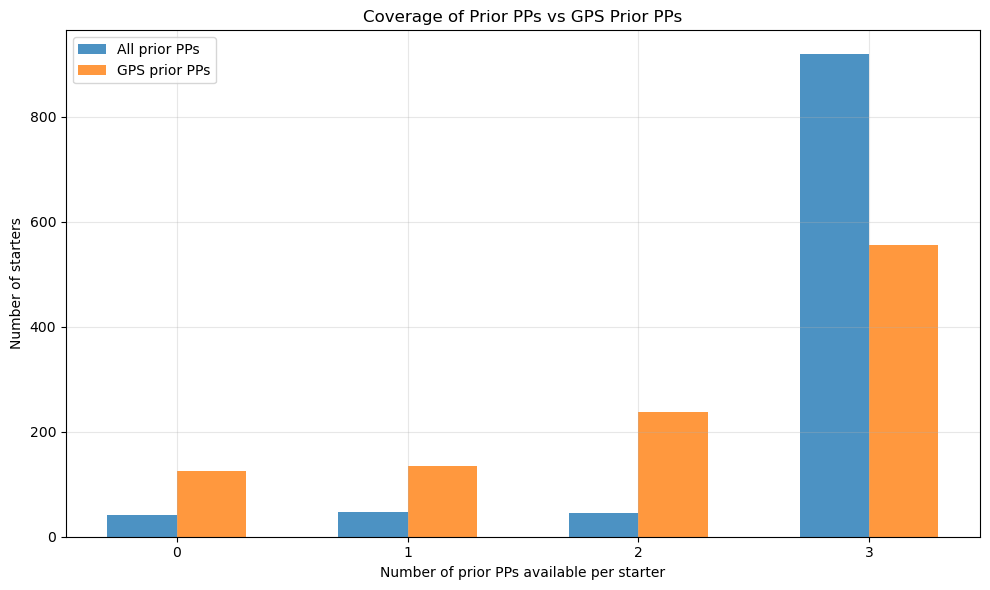

In [111]:
pp_distribution = (
    starter_coverage["num_prior_pps"]
    .value_counts()
    .sort_index()
)

gps_distribution = (
    starter_coverage["num_prior_gps_pps"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))
plt.bar(pp_distribution.index - 0.15, pp_distribution.values, width=0.3, alpha=0.8, label="All prior PPs")
plt.bar(gps_distribution.index + 0.15, gps_distribution.values, width=0.3, alpha=0.8, label="GPS prior PPs")

plt.xlabel("Number of prior PPs available per starter")
plt.ylabel("Number of starters")
plt.title("Coverage of Prior PPs vs GPS Prior PPs")
plt.xticks(sorted(set(pp_distribution.index).union(set(gps_distribution.index))))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

It might look confusing at first, but this graph makes sense. I probably would not use this for any illustration. But here what it means. You can see that more than half of all prior PPs don't have GPS data. Then, the ones that don't have GPS data will be added to columns before that. Thus, the missing from the 3 columns is distributed somewhere in the first 0, 1, and 2 columns. Same thing could happen for 2 and 1 prior PPs. Also, note that some horses are starter of multiple Laurel Park races. This could also affect the distribution too.

## 6. Train/Test Split

Given that there are quite a number horses that have Laurel Park as one of there previous race, we need a more careful approach to split the target into train and test set in order to avoid data leakage.

In [115]:
# Check how many horses that have pps as Laurel races
laurel_race_keys = set(
    laurel_raw["track_id"].astype(str).str.strip() + "_" +
    pd.to_datetime(laurel_raw["race_date"]).dt.strftime("%Y-%m-%d") + "_" +
    laurel_raw["race_number"].astype(str)
)

starter_pp_top3["pp_is_laurel_target_race"] = starter_pp_top3["pp_race_key"].isin(laurel_race_keys)

laurel_pp_overlap = (
    starter_pp_top3.groupby("starter_id")
    .agg(
        num_prior_target_laurel_pps=("pp_is_laurel_target_race", "sum")
    )
    .reset_index()
)

laurel_pp_overlap = starter_target.merge(
    laurel_pp_overlap,
    on="starter_id",
    how="left"
).fillna({"num_prior_target_laurel_pps": 0})

laurel_pp_overlap["num_prior_target_laurel_pps"] = (
    laurel_pp_overlap["num_prior_target_laurel_pps"].astype(int)
)

print("Starters with at least one prior PP that is also one of the 148 Laurel target races:")
print((laurel_pp_overlap["num_prior_target_laurel_pps"] > 0).sum())

print("\nDistribution of how many overlapping Laurel target PPs each starter has:")
print(laurel_pp_overlap["num_prior_target_laurel_pps"].value_counts().sort_index())

Starters with at least one prior PP that is also one of the 148 Laurel target races:
325

Distribution of how many overlapping Laurel target PPs each starter has:
num_prior_target_laurel_pps
0    729
1    266
2     57
3      2
Name: count, dtype: int64


This means some of the 1,054 starter rows are using earlier races from the same 148-race Laurel sample as past performances. More concretely:

* 325 starters have at least one prior PP that is also one of the 148 target Laurel races
* 266 starters have exactly 1 such overlap
* 57 staters have exactly 2 such overlaps
* 2 starters have exacctly 3 such overlaps
* And 729 starters have no such overlap

The repeating nature of this is not bad by itself. This is actually normal and often more desirable. If an earlier Laurel race happened before the race we are predicting, then using it as past performance is realistic. A handicapper would know that information before post time. Thus, an earlier target Laurel race used as PP for a later target Laurel race is just fine.

However, it is a data leakage if a later target laurel race somehow used as PP for an earlier race. Thus, we cannot randomly split the data into train and test set. Instead, a chronological split matters, given that the target set is interally connected.

For now, we will split target races by date of 80/20 ratio. We will train and the earlier races, and test on the later races. Also, when building features, we will only use PPs with a strictly earlier date than the target race. That way, overlapping Laurel races are allowed only in the correct direction: past -> future.

In [126]:
# Chronological race-level split to reduce leakage
race_order = (
    starter_target[["target_race_id", "race_date", "race_number"]]
    .drop_duplicates()
    .sort_values(["race_date", "race_number"])
    .reset_index(drop=True)
)

# Initial 80/20 split by race order
cut_index = int(0.8 * len(race_order))
cut_date  = race_order.loc[cut_index, "race_date"]

# Split by date boundary so the same date is not split across train/test
train_races = race_order.loc[race_order["race_date"] < cut_date, "target_race_id"]
test_races  = race_order.loc[race_order["race_date"] >= cut_date, "target_race_id"]

train_race_ids = set(train_races)
test_race_ids = set(test_races)

starter_target["split"] = np.where(starter_target["target_race_id"].isin(test_race_ids), "test", "train")

# Starter-level tables
train_target = starter_target[starter_target["split"] == "train"].copy()
test_target = starter_target[starter_target["split"] == "test"].copy()

# Race counts
print("Train races:", train_target["target_race_id"].nunique())
print("Test races:", test_target["target_race_id"].nunique())
print()

# Starter counts
print("Train starters:", len(train_target))
print("Test starters:", len(test_target))
print()

# Date ranges
print("Train date range:", train_target["race_date"].min(), "to", train_target["race_date"].max())
print("Test date range:", test_target["race_date"].min(), "to", test_target["race_date"].max())

Train races: 118
Test races: 30

Train starters: 830
Test starters: 224

Train date range: 2025-12-12 00:00:00 to 2026-01-17 00:00:00
Test date range: 2026-01-23 00:00:00 to 2026-02-05 00:00:00


In [127]:
# Sanity checks
assert starter_target['starter_id'].is_unique, 'starter_id should be unique after collapsing'
assert starter_target['target_race_id'].nunique() == 148, 'Expected 148 target races from the README'
assert starter_target['official_position'].notna().all(), 'Missing outcomes found'
assert starter_target['finish_score'].between(0, 1).all(), 'Target score should be in [0,1]'

starter_target.describe()

,race_date,race_number,distance_id,purse,post_position,official_position,field_size,finish_score,is_winner,is_top3
count,1054,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000
mean,2026-01-04 19:04:53.738140416,5.147059,6.948767,38516.627135,4.264706,4.243833,7.487666,0.500000,0.140417,0.421252
min,2025-12-12 00:00:00,1.000000,5.500000,18410.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000
25%,2025-12-20 00:00:00,3.000000,6.000000,24550.000000,2.000000,2.000000,6.000000,0.200000,0.000000,0.000000
50%,2025-12-28 00:00:00,5.000000,7.000000,29500.000000,4.000000,4.000000,7.000000,0.500000,0.000000,0.000000
75%,2026-01-17 00:00:00,7.000000,8.000000,49000.000000,6.000000,6.000000,9.000000,0.800000,0.000000,1.000000
max,2026-02-05 00:00:00,10.000000,9.000000,100000.000000,11.000000,11.000000,11.000000,1.000000,1.000000,1.000000
std,NaN,2.684450,1.151915,20955.555057,2.349991,2.342541,1.638027,0.333141,0.347585,0.493994


In [128]:
# Sanity check that no race appears in both lists
overlap = set(train_target["target_race_id"]).intersection(set(test_target["target_race_id"]))
print("Overlapping races:", len(overlap))

Overlapping races: 0


In [129]:
# Split proportions
print("Train proportion:", len(train_target) / len(starter_target))
print("Test proportion:", len(test_target) / len(starter_target))

Train proportion: 0.7874762808349146
Test proportion: 0.2125237191650854


Close enough. Now, we have a final look at the target table before we save it.

In [130]:
# First 10 rows of the starter_target
starter_target.head(10)

,starter_id,target_race_id,track_id,race_date,race_number,distance,distance_id,surface,race_type,purse,registration_number,horse_name,post_position,official_position,field_size,finish_score,is_winner,is_top3,split
0,LRL_2025-12-12_1_22010064,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22010064,Buckin' Right,1,2,8,0.857143,0,1,train
1,LRL_2025-12-12_1_22011846,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22011846,Rehoboth Avenue,2,4,8,0.571429,0,0,train
2,LRL_2025-12-12_1_21017739,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21017739,Sippin' Time,3,8,8,0.000000,0,0,train
3,LRL_2025-12-12_1_19002714,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,19002714,Mischief Motion,4,7,8,0.142857,0,0,train
4,LRL_2025-12-12_1_22004844,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004844,Over My Cents,5,6,8,0.285714,0,0,train
5,LRL_2025-12-12_1_22002156,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22002156,Mun Mun Can Run,6,3,8,0.714286,0,1,train
6,LRL_2025-12-12_1_22004645,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,22004645,Bourbon N Lace,7,1,8,1.000000,1,1,train
7,LRL_2025-12-12_1_21003278,LRL_2025-12-12_1,LRL,2025-12-12,1,7F,7.0,D,SOC,27900,21003278,Weekend Wife,8,5,8,0.428571,0,0,train
8,LRL_2025-12-12_2_20020224,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,20020224,Mosler Time,1,3,5,0.500000,0,1,train
9,LRL_2025-12-12_2_20016574,LRL_2025-12-12_2,LRL,2025-12-12,2,1 1/16M,8.5,D,SOC,40885,20016574,Feeling Woozy,2,1,5,1.000000,1,1,train


## 7. Save the Target Table

In [131]:
out = starter_target.copy()
out.to_parquet("../data/processed/starter_target.parquet", index=False)
out.to_csv("../data/processed/starter_target.csv", index=False)
print("Saved starter_target.parquet and .csv")

Saved starter_target.parquet and .csv


Also, we will save our current state of `pps_raw` and `gps_pp_raw` as .csv and .parquet for future feature engineering.

In [135]:
# Save pps_raw
pps_raw.to_parquet("../data/processed/pps.parquet", index=False)
pps_raw.to_csv("../data/processed/pps.csv", index=False)
print("Saved pps.parquet and .csv")

# Save gps_pp_raw
gps_pp_raw.to_parquet("../data/processed/gps_pp.parquet", index=False)
gps_pp_raw.to_csv("../data/processed/gps_pp.csv", index=False)
print("Saved gps_pp.parquet and .csv")

Saved pps.parquet and .csv
Saved gps_pp.parquet and .csv
